# Data Ingestion and Cleaning

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Libraries loaded successfully')

Libraries loaded successfully


## Step 1 - Load the Raw Data

In [5]:
RAW_PATH = 'online_retail_II.xlsx'

# Read all sheets
sheets = pd.read_excel(RAW_PATH, sheet_name=None, engine='openpyxl')
df_raw = pd.concat(sheets.values(), ignore_index=True)

print('Shape of dataset:', df_raw.shape)
print('Columns:', list(df_raw.columns))
print()
print('First few rows:')
display(df_raw.head())

Shape of dataset: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First few rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Step 2 - Check for Missing Values

In [6]:
print(' Missing Values ')
missing = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)

null_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percent': missing_pct,
    'Data Type': df_raw.dtypes
})
display(null_summary)

# duplicates
num_duplicates = df_raw.duplicated().sum()
print(f'\nNumber of duplicate rows: {num_duplicates}')

# cancellations
cancellations = df_raw['Invoice'].astype(str).str.startswith('C').sum()
print(f'Number of cancellation rows: {cancellations}')

# negative quantities
negative_qty = (df_raw['Quantity'] < 0).sum()
print(f'Rows with negative quantity: {negative_qty}')

# negative or zero price
bad_price = (df_raw['Price'] <= 0).sum()
print(f'Rows with zero or negative price: {bad_price}')

 Missing Values 


,Missing Count,Missing Percent,Data Type
Invoice,0,0.00,object
StockCode,0,0.00,object
Description,4382,0.41,object
Quantity,0,0.00,int64
InvoiceDate,0,0.00,datetime64[ns]
Price,0,0.00,float64
Customer ID,243007,22.77,float64
Country,0,0.00,object



Number of duplicate rows: 34335
Number of cancellation rows: 19494
Rows with negative quantity: 22950
Rows with zero or negative price: 6207


## Step 3 - Visualise the Raw Data Problems

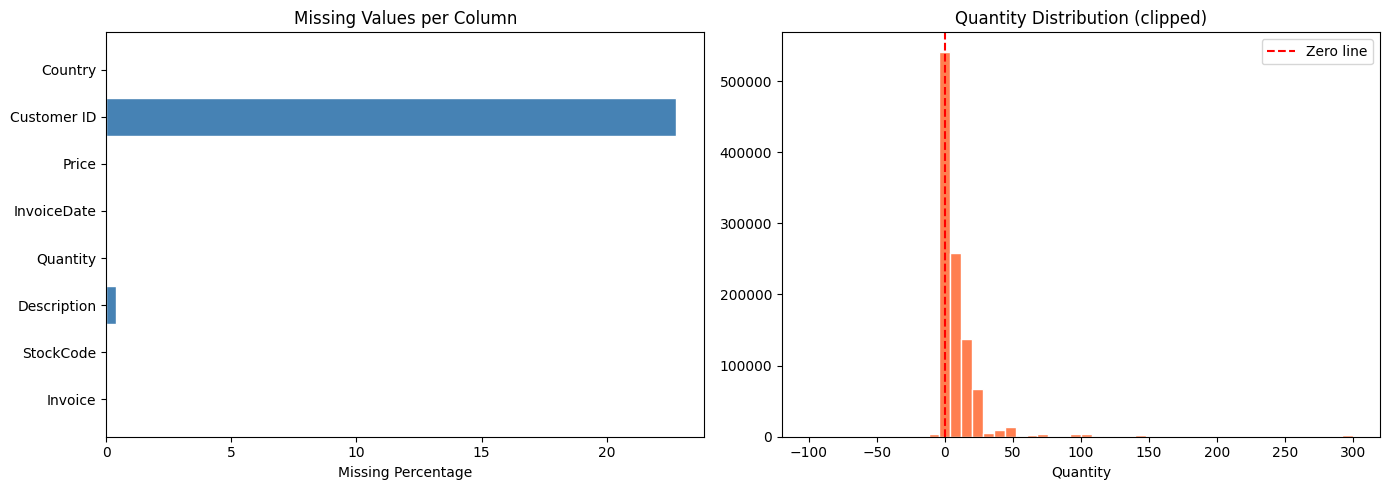

Figure saved


In [7]:
# plotting missing values and quantity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# missing value bar chart
miss_pct = df_raw.isnull().mean() * 100
axes[0].barh(miss_pct.index, miss_pct.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Missing Percentage')
axes[0].set_title('Missing Values per Column')

# quantity distribution
qty_clip = df_raw['Quantity'].clip(-100, 300)
axes[1].hist(qty_clip, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', label='Zero line')
axes[1].set_title('Quantity Distribution (clipped)')
axes[1].set_xlabel('Quantity')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/fig_01_data_audit.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved')

## Step 4 - Data Cleaning

In [8]:
df = df_raw.copy()
step_counts = {}

step_counts['01 raw data'] = len(df)
print(f"Starting rows: {len(df):,}")

# remove duplicates
df = df.drop_duplicates()
step_counts['02 remove duplicates'] = len(df)
print(f"After removing duplicates: {len(df):,}")

# remove cancellation invoices
df = df[~df['Invoice'].astype(str).str.startswith('C')]
step_counts['03 remove cancellations'] = len(df)
print(f"After removing cancellations: {len(df):,}")

valid_code = r'^\d{5}[A-Za-z]{0,2}$'
df = df[df['StockCode'].astype(str).str.match(valid_code)]
step_counts['04 valid stock codes'] = len(df)
print(f"After removing invalid stock codes: {len(df):,}")

# remove zero or negative prices
df = df[df['Price'] > 0]
step_counts['05 positive price'] = len(df)
print(f"After removing bad prices: {len(df):,}")

# remove zero or negative quantities
df = df[df['Quantity'] > 0]
step_counts['06 positive quantity'] = len(df)
print(f"After removing bad quantities: {len(df):,}")

# remove rows with no customer id
df = df.dropna(subset=['Customer ID'])
step_counts['07 has customer id'] = len(df)
print(f"After removing missing customer IDs: {len(df):,}")

print()
print(f"Total rows removed: {step_counts['01 raw data'] - len(df):,}")
print(f"Remaining rows: {len(df):,}")

Starting rows: 1,067,371
After removing duplicates: 1,033,036
After removing cancellations: 1,013,932
After removing invalid stock codes: 1,009,141
After removing bad prices: 1,003,213
After removing bad quantities: 1,003,213
After removing missing customer IDs: 776,577

Total rows removed: 290,794
Remaining rows: 776,577


## Step 5 - Fix Data Types and Create Revenue Column

In [9]:
# fixing data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)
df['Invoice'] = df['Invoice'].astype(str)
df['StockCode'] = df['StockCode'].astype(str)

# creating revenue column
df['Revenue'] = (df['Quantity'] * df['Price']).round(2)

print('Date range:', df['InvoiceDate'].min(), 'to', df['InvoiceDate'].max())
print('Unique customers:', df['Customer ID'].nunique())
print('Unique products:', df['StockCode'].nunique())
print('Unique invoices:', df['Invoice'].nunique())
print('Total revenue: £', df['Revenue'].sum().round(2))
print()
display(df.head())

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5852
Unique products: 4619
Unique invoices: 36594
Total revenue: £ 17068567.97



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


## Step 6 - Handle Outliers Using IQR Method

In [10]:
# using IQR method to cap outliers instead of removing them
def get_iqr_bounds(column, multiplier=3.0):
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    return lower, upper

df_clean = df.copy()

for col in ['Quantity', 'Price']:
    low, high = get_iqr_bounds(df_clean[col])
    before = df_clean[col].describe()
    df_clean[col] = df_clean[col].clip(low, high)
    after = df_clean[col].describe()
    outliers_capped = ((df[col] < low) | (df[col] > high)).sum()
    print(f'{col}: capped {outliers_capped} outliers  (bounds: {low:.2f} to {high:.2f})')

# recalculate revenue after capping
df_clean['Revenue'] = (df_clean['Quantity'] * df_clean['Price']).round(2)
print()
print('Outlier capping done')

Quantity: capped 36741 outliers  (bounds: -28.00 to 42.00)
Price: capped 16822 outliers  (bounds: -6.25 to 11.25)

Outlier capping done


## Step 7 - Plot Outlier Effect

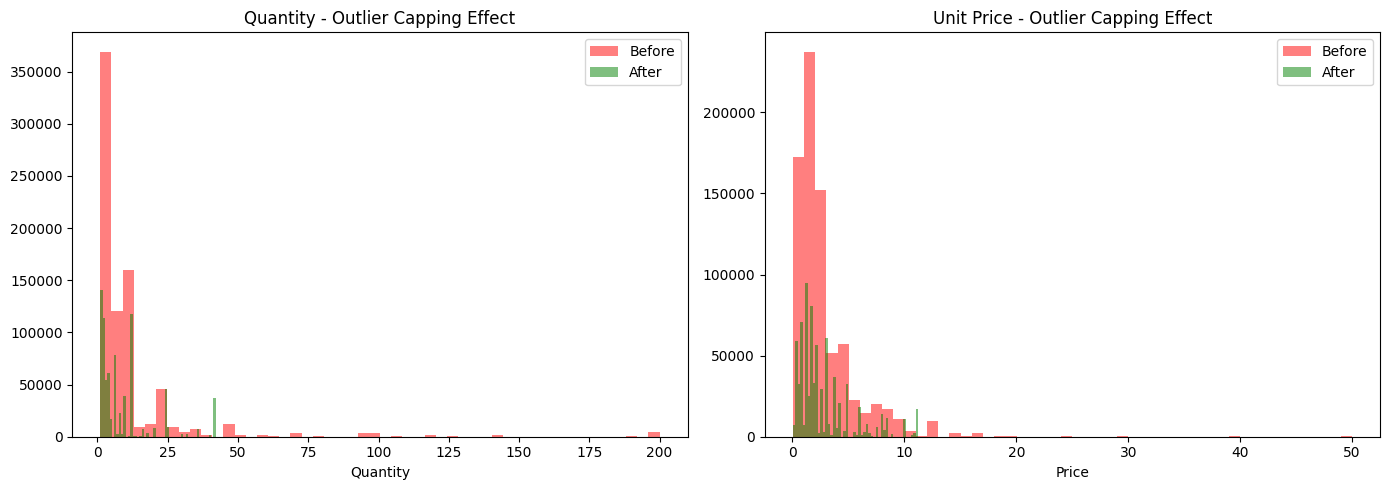

Figure saved


In [11]:
# showing before and after for outlier capping
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# quantity before vs after
axes[0].hist(df['Quantity'].clip(0, 200), bins=50, color='red', alpha=0.5, label='Before')
axes[0].hist(df_clean['Quantity'].clip(0, 200), bins=50, color='green', alpha=0.5, label='After')
axes[0].set_title('Quantity - Outlier Capping Effect')
axes[0].set_xlabel('Quantity')
axes[0].legend()

# price before vs after
axes[1].hist(df['Price'].clip(0, 50), bins=50, color='red', alpha=0.5, label='Before')
axes[1].hist(df_clean['Price'].clip(0, 50), bins=50, color='green', alpha=0.5, label='After')
axes[1].set_title('Unit Price - Outlier Capping Effect')
axes[1].set_xlabel('Price')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/fig_02_outliers.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved')

## Step 8 - Exploratory Analysis

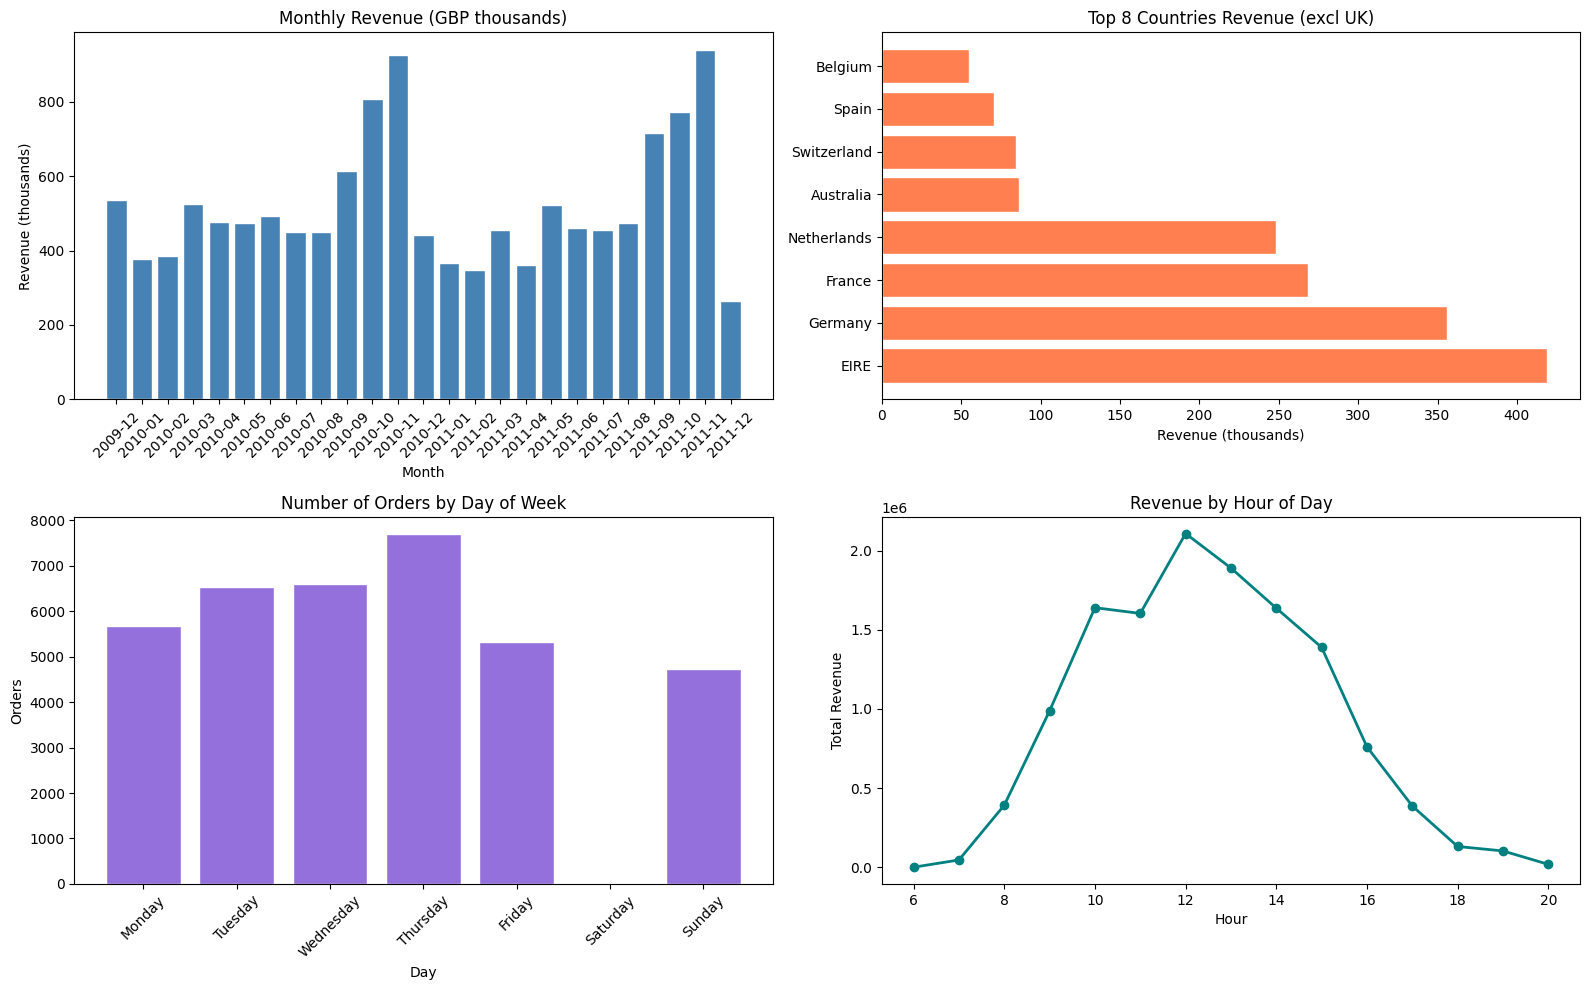

Figure saved


In [12]:
# looking at monthly revenue and top countries
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# monthly revenue
monthly = df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['Revenue'].sum().reset_index()
monthly['InvoiceDate'] = monthly['InvoiceDate'].astype(str)

axes[0][0].bar(monthly['InvoiceDate'], monthly['Revenue'] / 1000, color='steelblue', edgecolor='white')
axes[0][0].set_title('Monthly Revenue (GBP thousands)')
axes[0][0].set_xlabel('Month')
axes[0][0].set_ylabel('Revenue (thousands)')
axes[0][0].tick_params(axis='x', rotation=45)

# revenue by country (excluding UK)
country_rev = (df_clean[df_clean['Country'] != 'United Kingdom']
               .groupby('Country')['Revenue'].sum()
               .sort_values(ascending=False)
               .head(8))
axes[0][1].barh(country_rev.index, country_rev.values / 1000, color='coral', edgecolor='white')
axes[0][1].set_title('Top 8 Countries Revenue (excl UK)')
axes[0][1].set_xlabel('Revenue (thousands)')

# orders per day of week
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orders_by_day = df_clean.groupby('DayOfWeek')['Invoice'].nunique().reindex(day_order)
axes[1][0].bar(orders_by_day.index, orders_by_day.values, color='mediumpurple', edgecolor='white')
axes[1][0].set_title('Number of Orders by Day of Week')
axes[1][0].set_xlabel('Day')
axes[1][0].set_ylabel('Orders')
axes[1][0].tick_params(axis='x', rotation=45)

# revenue per hour
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
hourly_rev = df_clean.groupby('Hour')['Revenue'].sum()
axes[1][1].plot(hourly_rev.index, hourly_rev.values, color='teal', marker='o', linewidth=2)
axes[1][1].set_title('Revenue by Hour of Day')
axes[1][1].set_xlabel('Hour')
axes[1][1].set_ylabel('Total Revenue')

plt.tight_layout()
plt.savefig('data/fig_03_eda.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved')

## Step 9 - Save the Clean Data

In [13]:
import os
os.makedirs('data', exist_ok=True)

SILVER_PATH = 'data/silver_retail.parquet'
df_clean.to_parquet(SILVER_PATH, index=False, engine='pyarrow')

print('Clean data saved to:', SILVER_PATH)
print('Shape:', df_clean.shape)
print('File size:', round(os.path.getsize(SILVER_PATH) / 1e6, 2), 'MB')
print()
print('Column list:')
for col in df_clean.columns:
    print(' ', col, '-', df_clean[col].dtype)

Clean data saved to: data/silver_retail.parquet
Shape: (776577, 11)
File size: 6.13 MB

Column list:
  Invoice - object
  StockCode - object
  Description - object
  Quantity - int64
  InvoiceDate - datetime64[ns]
  Price - float64
  Customer ID - object
  Country - object
  Revenue - float64
  DayOfWeek - object
  Hour - int32
